In [1]:
import pandas as pd

df = pd.read_csv("../data/email.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5573 non-null   str  
 1   Message   5573 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [3]:
df['Category'].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [4]:
df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

In [5]:
df.head()

,Category,Message
0,0.0,"Go until jurong point, crazy.. Available only ..."
1,0.0,Ok lar... Joking wif u oni...
2,1.0,Free entry in 2 a wkly comp to win FA Cup fina...
3,0.0,U dun say so early hor... U c already then say...
4,0.0,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df['clean_message'] = df['Message'].apply(clean_text) #text cleaning

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_message'])
y = df['Category']    #extraction

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)  #train and split

In [13]:
df.columns

Index(['Category', 'Message', 'clean_message'], dtype='str')

In [14]:
df['Category'].unique()

array([ 0.,  1., nan])

In [15]:
df['Category'].unique()

array([ 0.,  1., nan])

In [16]:
df = df.dropna(subset=['Category'])

In [17]:
df['Category'].unique()

array([0., 1.])

In [18]:
X = tfidf.fit_transform(df['clean_message'])
y = df['Category']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98       966
         1.0       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



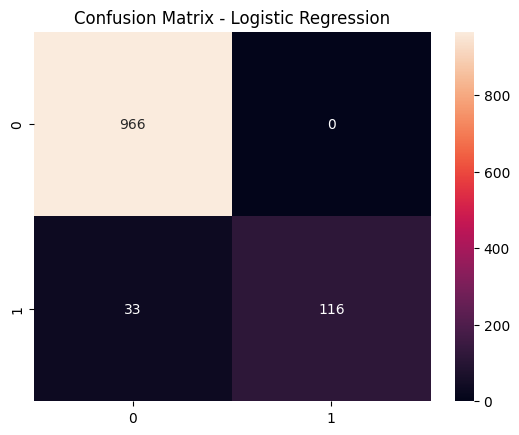

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [24]:
df = pd.read_csv("../data/email.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
df = df.dropna(subset=['Category'])

In [26]:
df['Category'] = df['Category'].map({
    'ham':0,
    'spam':1
})

In [27]:
import re

def clean_text(text):
    
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    
    return text

In [28]:
df['clean_message'] = df['Message'].apply(clean_text)

df.head()

,Category,Message,clean_message
0,0.0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0.0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1.0,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,0.0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0.0,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [29]:
tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(df['clean_message'])

y = df['Category']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
df = df.dropna(subset=['Category'])

In [33]:
df['Category'].unique()

array([0., 1.])

In [34]:
tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(df['clean_message'])

y = df['Category']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
y_train.isna().sum()

np.int64(0)

In [37]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98       966
         1.0       1.00      0.70      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



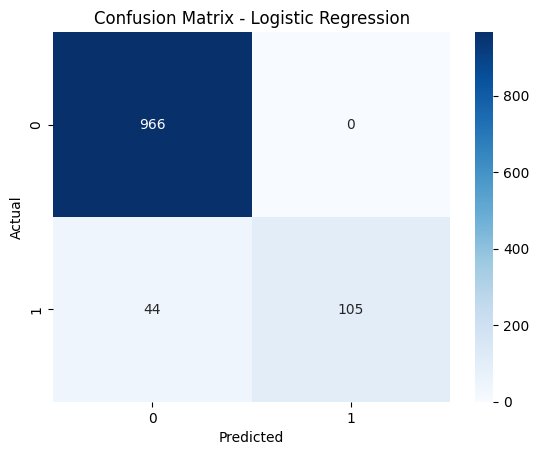

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
plt.savefig("../results/logistic_confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [41]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_nb))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98       966
         1.0       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



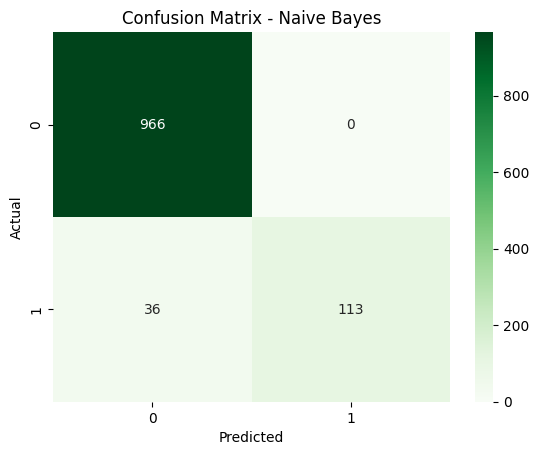

In [43]:
cm_nb = confusion_matrix(y_test, pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap="Greens")

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [44]:
plt.savefig("../results/naive_bayes_confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

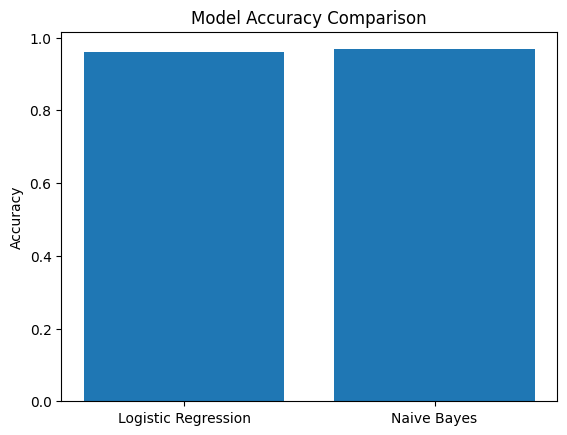

In [45]:
models = ["Logistic Regression", "Naive Bayes"]

accuracy = [
    accuracy_score(y_test, pred_lr),
    accuracy_score(y_test, pred_nb)
]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [46]:
plt.savefig("../results/model_accuracy_comparison.png")

<Figure size 640x480 with 0 Axes>